# Week 11 — live coding (completed)

**Social and Cultural Analytics (7AAVBCS5)**

The filled-in version.

In [1]:
import re
import subprocess
import sys
from pathlib import Path


def ensure(package: str) -> None:
    """Install a package if it is missing.

    Nothing happens on your own machine, where the setup instructions already
    installed everything. On Colab, which starts bare each session, this fills
    in whatever is not preinstalled.
    """
    import importlib

    try:
        importlib.import_module(package)
        return
    except ImportError:
        pass

    print(f"Installing {package} (once)...")
    for attempt in (1, 2):
        done = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package],
            capture_output=True,
            text=True,
        )
        if done.returncode == 0:
            importlib.invalidate_caches()
            return
        if attempt == 1:
            print("  that did not work; trying once more...")
    raise RuntimeError(
        f"Could not install {package}, which this week needs. This is almost always "
        f"a network problem.\n\n"
        f"Run this in a cell of its own, then re-run this one:\n"
        f"    !pip install {package}\n\n"
        f"pip said:\n{done.stderr.strip()[-400:]}"
    )

ensure("vaderSentiment")

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# The module's data lives in a separate public repository so that this notebook
# works both on your own machine and on Colab.
DATA_REPO = "https://github.com/markjhill/7AAVBCS5-data.git"


def data_path(name: str) -> Path:
    """Return a usable path to a file or folder in the module's data folder.

    A notebook's "current folder" is wherever it was opened from, which differs
    between Positron and Colab and is the usual cause of FileNotFoundError. So
    rather than assuming, we search upwards for a `data` folder. If there isn't
    one -- which means we are on Colab -- the public data repository is
    downloaded once and used instead.

    Works for single files ("museum_data.csv") and for folders ("SUA").
    """
    here = Path.cwd()
    for candidate in (here, *here.parents):
        local = candidate / "data" / name
        if local.exists():
            return local

    downloaded = Path("7AAVBCS5-data")
    if not downloaded.is_dir():
        print("No local data folder found -- downloading the module data (once)...")
        subprocess.run(
            ["git", "clone", "--depth", "1", DATA_REPO, str(downloaded)],
            check=True,
        )
    target = downloaded / name
    if not target.exists():
        raise FileNotFoundError(f"{name!r} is not in the module data.")
    return target


analyser = SentimentIntensityAnalyzer()

docs, names, years = [], [], []
for path in sorted((data_path("SUA")).glob("*.txt")):
    text = path.read_text(encoding="utf-8", errors="replace")
    if text.strip():
        docs.append(text)
        names.append(path.stem)
        years.append(int(path.stem.split("_")[1]))

print(len(docs), "speeches")

227 speeches


## 1. A document-term matrix

In [2]:
vec = CountVectorizer(stop_words="english", min_df=10, max_df=0.9)
dtm = vec.fit_transform(docs)
print(f"{dtm.shape[0]} documents x {dtm.shape[1]} terms")
print(f"sparsity {100 * (1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1])):.1f}%")

227 documents x 7096 terms
sparsity 81.6%


## 2. LDA -- first attempt

In [3]:
lda = LatentDirichletAllocation(n_components=5, random_state=0, max_iter=10).fit(dtm)
terms = vec.get_feature_names_out()
for k, c in enumerate(lda.components_):
    print(f"topic {k}: " + ", ".join(terms[i] for i in c.argsort()[-8:][::-1]))

topic 0: 000, general, service, department, law, secretary, foreign, fiscal
topic 1: shall, present, subject, mexico, constitution, general, treaty, necessary
topic 2: law, 000, men, present, business, work, shall, service
topic 3: 000, present, treasury, debt, general, condition, duties, currency
topic 4: world, america, work, americans, security, help, federal, program


Two problems. **`000` is a top term** — numbers survived pre-processing. And the topics have
separated **eras**, not subjects: nineteenth-century fiscal language against twentieth-century
programme language.

## 3. Fix the pre-processing

In [4]:
vec2 = CountVectorizer(stop_words="english", min_df=10, max_df=0.9,
                       token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")
dtm2 = vec2.fit_transform(docs)
terms2 = vec2.get_feature_names_out()

lda2 = LatentDirichletAllocation(n_components=5, random_state=0, max_iter=10).fit(dtm2)
for k, c in enumerate(lda2.components_):
    print(f"topic {k}: " + ", ".join(terms2[i] for i in c.argsort()[-8:][::-1]))

topic 0: law, service, work, men, department, present, general, business
topic 1: federal, legislation, fiscal, expenditures, dollars, economic, present, administration
topic 2: present, general, subject, shall, treaty, treasury, constitution, mexico
topic 3: america, work, americans, tonight, let, children, jobs, help
topic 4: world, economic, free, federal, america, program, security, help


Much more readable. Note `tonight` — a word that only enters once the address became a televised
evening event.

**Nothing told us this was better. We looked and judged.** That is standard practice, and it has to
be reported as judgement rather than as a result.

### And it is non-deterministic

In [5]:
lda42 = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=10).fit(dtm2)
for k, c in enumerate(lda42.components_):
    print(f"topic {k}: " + ", ".join(terms2[i] for i in c.argsort()[-6:][::-1]))

topic 0: world, federal, program, economic, security, free
topic 1: world, shall, men, present, necessary, right
topic 2: america, world, americans, work, let, help
topic 3: law, work, business, service, men, legislation
topic 4: general, present, subject, shall, treaty, treasury


Different seed, different topics. **Set `random_state` and report it**, or your results cannot be
reproduced.

## 4. Sentiment on a whole document -- and why it fails

In [6]:
for s in ["This is a wonderful and hopeful day.", "I am happy", "I am not happy"]:
    print(f"{s:38} {analyser.polarity_scores(s)['compound']:+.4f}")

This is a wonderful and hopeful day.   +0.7906
I am happy                             +0.5719
I am not happy                         -0.4585


VADER handles negation. Note that `not` is a **stop word** — so removing stop words before
sentiment analysis destroys the thing the method depends on.

In [7]:
for i in [0, len(docs) // 2, len(docs) - 1]:
    print(f"{names[i]:26} {analyser.polarity_scores(docs[i])['compound']:+.4f}")

Adams_1797                 +0.9996


Johnson_1868               +1.0000
Wilson_1920                +0.9998


**Every speech scores about 0.9999.** The compound score is a normalised sum, so it saturates on
long text. Real number, reproducible, meaningless.

## 5. Sentiment by sentence

In [8]:
def sentence_sentiment(text, limit=400):
    """Mean VADER compound across the sentences of a text."""
    sentences = [s for s in re.split(r"(?<=[.!?])\s+", text) if len(s.split()) > 3]
    if not sentences:
        return None
    return sum(analyser.polarity_scores(s)["compound"] for s in sentences[:limit]) / len(sentences[:limit])


sentiment = pd.DataFrame({
    "name": names,
    "year": years,
    "mean_compound": [sentence_sentiment(d) for d in docs],
})
print(sentiment["mean_compound"].describe().round(3).to_string())

count    227.000
mean       0.239
std        0.088
min       -0.029
25%        0.186
50%        0.243
75%        0.295
max        0.579


Now it varies: about −0.03 to +0.58. Same texts, same lexicon — only the **unit of analysis**
changed.

In [9]:
print("least positive:")
print(sentiment.nsmallest(5, "mean_compound")[["name", "mean_compound"]].to_string(index=False))

least positive:
          name  mean_compound
Roosevelt_1942      -0.029204
Roosevelt_1943      -0.010641
Roosevelt_1944      -0.005865
     Bush_2003       0.026929
Roosevelt_1938       0.042810


**Roosevelt 1942, 1943, 1944.** The three most negative addresses in 227 years are the Second World
War. The method recovered that from word choice alone — which is the best evidence we have that it
is measuring something.

## 6. Sentiment over time

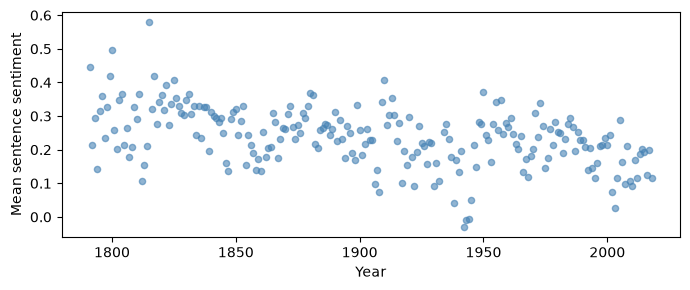

correlation: -0.459


In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(sentiment["year"], sentiment["mean_compound"], alpha=0.6, s=20, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Mean sentence sentiment")
plt.tight_layout()
plt.show()

print("correlation:", round(sentiment["year"].corr(sentiment["mean_compound"]), 3))

r = −0.46. Addresses have become measurably less positive.

**Two explanations, and this corpus cannot separate them.** Either politics got harder, or
nineteenth-century political prose was simply more florid and a modern lexicon rewards that. To
distinguish them you would need another genre over the same period.

Saying so is the analysis. That is §5.5, and it is the last thing this module has to teach.

End of live coding.